# ISIC Skin Cancer Detection: Comprehensive Model Analysis

This notebook provides a complete analysis of all models trained for the ISIC 2024 competition. It demonstrates the progression from simple CNNs to advanced hybrid architectures with ensemble methods.

**Purpose**: Load and evaluate all trained models without retraining
- Understand model architectures and their evolution
- Compare validation and test performance across approaches
- Analyze which techniques provided the most improvement
- Visualize the learning journey from baseline to state-of-the-art

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print(" "*20 + "ISIC 2024 MODEL ANALYSIS")
print("="*80)
print("\nLoading and analyzing all trained models...")
print("="*80 + "\n")

                    ISIC 2024 MODEL ANALYSIS

Loading and analyzing all trained models...



## 1. Model Evolution Overview

This section scans all results directories and catalogs the models you've trained, showing the evolution of your approach.

In [2]:
results_base = Path('results')

# Scan for all model results
model_registry = {
    'baseline_hybrid': {
        'pattern': 'hybrid_model_*',
        'description': 'Baseline Hybrid (Custom CNN + Metadata)',
        'notebook': '3_hybrid_cnn_metadata.ipynb',
        'key_features': ['Simple CNN', 'Metadata fusion', 'Focal Loss']
    },
    'efficientnetv2_hybrid': {
        'pattern': 'efficientnet_v2_hybrid_*',
        'description': 'EfficientNetV2-S Hybrid',
        'notebook': '4_hybrid_cnn_metadata_EfficientNet-v2.ipynb',
        'key_features': ['Transfer Learning', 'ImageNet pretrained', 'Faster training']
    },
    'resnet34_hybrid': {
        'pattern': 'resnet34_hybrid_*',
        'description': 'ResNet34 Hybrid',
        'notebook': '5_hybrid_cnn_metadata_ResNet34.ipynb',
        'key_features': ['ResNet backbone', 'Deep residual learning', 'Stable training']
    },
    'simple_ensemble': {
        'pattern': 'ensemble_*',
        'description': 'Simple 3-Model Ensemble',
        'notebook': '6_hybrid_cnn_metadata_ensemble.ipynb',
        'key_features': ['Weighted averaging', 'Multiple strategies', 'Diversity benefits']
    },
    'kfold_ensemble': {
        'pattern': 'kfold_efficientnetv2_*',
        'description': 'K-Fold Cross-Validation Ensemble',
        'notebook': '8_1_hybrid_cnn_metadata_kfold_ensemble.ipynb',
        'key_features': ['5-fold CV', 'Reduced overfitting', 'Robust predictions']
    },
    'v2s_features': {
        'pattern': 'v2s_features_*',
        'description': 'EfficientNetV2-S + Advanced Features',
        'notebook': '10_1_train_v2s_with_features.py',
        'key_features': ['Feature engineering', 'Age groups', 'Size categories']
    },
    'convnext_features': {
        'pattern': 'convnext_features_*',
        'description': 'ConvNeXt + Advanced Features',
        'notebook': '10_2_train_convnext_with_features.py',
        'key_features': ['Modern architecture', 'Layer normalization', 'GELU activation']
    },
    'vit_features': {
        'pattern': 'vit_features_*',
        'description': 'Vision Transformer (ViT) + Features',
        'notebook': '10_3_train_vit_with_features.py',
        'key_features': ['Attention mechanism', 'Patch embeddings', 'Transformer blocks']
    },
    'kfold_advanced': {
        'pattern': 'kfold_v2s_features_advanced_*',
        'description': 'K-Fold with Advanced Features',
        'notebook': '11_1_kfold_train_v2s_features_advanced.py',
        'key_features': ['5-fold + features', 'Best of both worlds', 'Maximum robustness']
    },
    'gbdt_stacking': {
        'pattern': 'gbdt_stacking_*',
        'description': 'GBDT Stacking (2nd Level Model)',
        'notebook': '12_1_gbdt_stacking.py',
        'key_features': ['Meta-learning', 'Gradient boosting', 'Stacked ensemble']
    }
}

# Find latest directory for each model type
available_models = {}
for model_key, model_info in model_registry.items():
    dirs = sorted(results_base.glob(model_info['pattern']))
    if dirs:
        latest_dir = dirs[-1]
        available_models[model_key] = {
            'path': latest_dir,
            'description': model_info['description'],
            'notebook': model_info['notebook'],
            'key_features': model_info['key_features']
        }

print(f"Found {len(available_models)} model types:\n")
for idx, (key, info) in enumerate(available_models.items(), 1):
    print(f"{idx}. {info['description']}")
    print(f"   Directory: {info['path']}")
    print(f"   Source: {info['notebook']}")
    print(f"   Features: {', '.join(info['key_features'])}")
    print()

Found 10 model types:

1. Baseline Hybrid (Custom CNN + Metadata)
   Directory: results/hybrid_model_20251110_090023
   Source: 3_hybrid_cnn_metadata.ipynb
   Features: Simple CNN, Metadata fusion, Focal Loss

2. EfficientNetV2-S Hybrid
   Directory: results/efficientnet_v2_hybrid_20251107_182005
   Source: 4_hybrid_cnn_metadata_EfficientNet-v2.ipynb
   Features: Transfer Learning, ImageNet pretrained, Faster training

3. ResNet34 Hybrid
   Directory: results/resnet34_hybrid_20251107_182054
   Source: 5_hybrid_cnn_metadata_ResNet34.ipynb
   Features: ResNet backbone, Deep residual learning, Stable training

4. Simple 3-Model Ensemble
   Directory: results/ensemble_20251108_135230
   Source: 6_hybrid_cnn_metadata_ensemble.ipynb
   Features: Weighted averaging, Multiple strategies, Diversity benefits

5. K-Fold Cross-Validation Ensemble
   Directory: results/kfold_efficientnetv2_20251108_171356
   Source: 8_1_hybrid_cnn_metadata_kfold_ensemble.ipynb
   Features: 5-fold CV, Reduced overfi

## 2. Load Model Performance Metrics

Extract performance metrics from each trained model's results files.

In [15]:
def load_model_metrics(model_path):
    """
    Load training metrics from a model results directory.
    Returns: dict with key metrics or None if not available
    """
    metrics = {
        'best_val_auc': None,
        'num_epochs': None,
        'training_time_min': None,
        'total_params': None,
        'trainable_params': None,
        'batch_size': None
    }
    
    # Try to load from different possible files
    config_file = model_path / 'training_config.json'
    results_pkl = model_path / 'training_results.pkl'
    
    # Load from JSON config
    if config_file.exists():
        with open(config_file, 'r') as f:
            config = json.load(f)
            metrics['best_val_auc'] = config.get('best_auc')
            metrics['num_epochs'] = config.get('num_epochs')
            metrics['training_time_min'] = config.get('total_time_minutes')
            metrics['total_params'] = config.get('total_params')
            metrics['trainable_params'] = config.get('trainable_params')
            metrics['batch_size'] = config.get('batch_size')
    
    # Load from pickle (more complete data)
    elif results_pkl.exists():
        with open(results_pkl, 'rb') as f:
            results = pickle.load(f)
            metrics['best_val_auc'] = results.get('best_auc')
            metrics['num_epochs'] = results.get('num_epochs', len(results.get('history', {}).get('train_auc', [])))
            metrics['training_time_min'] = results.get('total_time', 0) / 60
            metrics['total_params'] = results.get('total_params')
            metrics['trainable_params'] = results.get('trainable_params')
            metrics['batch_size'] = results.get('batch_size')
    
    # For ensemble models, check metadata
    ensemble_meta = model_path / 'ensemble_metadata.json'
    if ensemble_meta.exists():
        with open(ensemble_meta, 'r') as f:
            meta = json.load(f)
            metrics['estimated_lb'] = meta.get('estimated_best_lb')
            metrics['recommended_strategy'] = meta.get('recommended_strategy')
    
    return metrics

# Collect all metrics
all_metrics = []

for model_key, model_info in available_models.items():
    metrics = load_model_metrics(model_info['path'])
    
    if metrics['best_val_auc'] is not None:
        all_metrics.append({
            'Model': model_info['description'],
            'Key': model_key,
            'Val AUC': metrics['best_val_auc'],
            'Epochs': metrics['num_epochs'],
            'Time (min)': metrics['training_time_min'],
            'Parameters': metrics['total_params'],
            'Trainable': metrics['trainable_params'],
            'Batch Size': metrics['batch_size'],
            'Path': str(model_info['path'])
        })

# Create DataFrame for easy viewing
metrics_df = pd.DataFrame(all_metrics)

if len(metrics_df) > 0:
    # Sort by validation AUC
    metrics_df = metrics_df.sort_values('Val AUC', ascending=False)
    
    print("="*80)
    print("MODEL PERFORMANCE SUMMARY")
    print("="*80 + "\n")
    
    # Display formatted table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    print(metrics_df[['Model', 'Val AUC', 'Epochs', 'Time (min)', 'Parameters']].to_string(index=False))
    print("\n" + "="*80 + "\n")
    
    # Best model
    best_model = metrics_df.iloc[0]
    print(f"🏆 Best Model: {best_model['Model']}")
    print(f"   Validation AUC: {best_model['Val AUC']:.4f}")
    print(f"   Training time: {best_model['Time (min)']:.1f} minutes")
    print(f"   Parameters: {int(best_model['Parameters']):,}")
    print()
else:
    print("⚠️ No model metrics found. Models may not have training_config.json files.")

MODEL PERFORMANCE SUMMARY

                                  Model  Val AUC  Epochs  Time (min)  Parameters
                EfficientNetV2-S Hybrid 0.950846      25  122.911871  20567569.0
   EfficientNetV2-S + Advanced Features 0.947586      30  147.829117         NaN
                        ResNet34 Hybrid 0.938013      25   63.221070  21478145.0
    Vision Transformer (ViT) + Features 0.935292      20  462.238927         NaN
           ConvNeXt + Advanced Features 0.934149      30  792.097867         NaN
Baseline Hybrid (Custom CNN + Metadata) 0.915174      30   88.388545  26272513.0


🏆 Best Model: EfficientNetV2-S Hybrid
   Validation AUC: 0.9508
   Training time: 122.9 minutes
   Parameters: 20,567,569



## 3. Visualize Model Performance Comparison

Create visualizations comparing all models across key metrics.

✓ Visualizations saved to: results/model_analysis/comprehensive_model_comparison.png



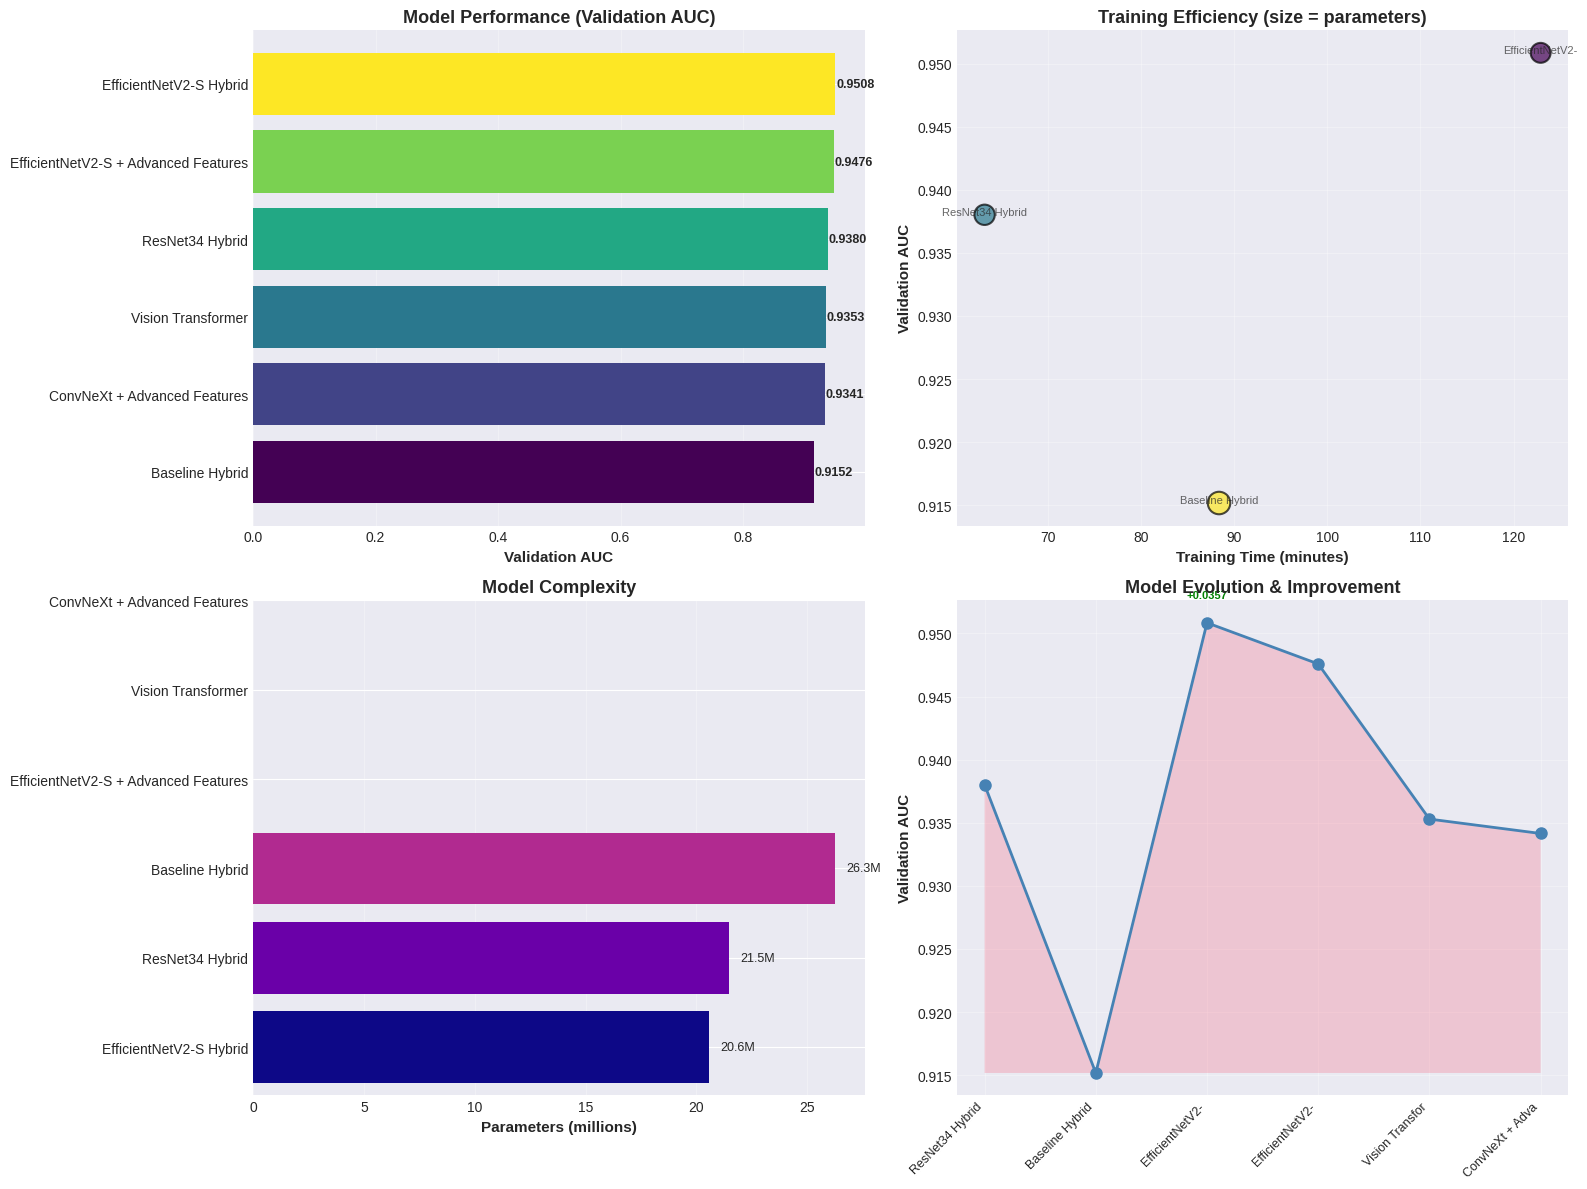

In [4]:
if len(metrics_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Validation AUC comparison
    ax1 = axes[0, 0]
    models_sorted = metrics_df.sort_values('Val AUC')
    colors = plt.cm.viridis(np.linspace(0, 1, len(models_sorted)))
    bars = ax1.barh(range(len(models_sorted)), models_sorted['Val AUC'], color=colors)
    ax1.set_yticks(range(len(models_sorted)))
    ax1.set_yticklabels([m.split('(')[0].strip() for m in models_sorted['Model']], fontsize=10)
    ax1.set_xlabel('Validation AUC', fontsize=11, fontweight='bold')
    ax1.set_title('Model Performance (Validation AUC)', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, models_sorted['Val AUC'])):
        ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    
    # 2. Training time vs Performance
    ax2 = axes[0, 1]
    scatter = ax2.scatter(metrics_df['Time (min)'], metrics_df['Val AUC'], 
                         s=metrics_df['Parameters']/100000, 
                         c=range(len(metrics_df)), cmap='viridis', 
                         alpha=0.7, edgecolors='black', linewidth=1.5)
    ax2.set_xlabel('Training Time (minutes)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Validation AUC', fontsize=11, fontweight='bold')
    ax2.set_title('Training Efficiency (size = parameters)', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Annotate points
    for idx, row in metrics_df.iterrows():
        ax2.annotate(row['Model'].split('(')[0].strip()[:15], 
                    (row['Time (min)'], row['Val AUC']),
                    fontsize=8, alpha=0.7, ha='center')
    
    # 3. Model size comparison
    ax3 = axes[1, 0]
    models_by_size = metrics_df.sort_values('Parameters')
    colors_size = plt.cm.plasma(np.linspace(0, 1, len(models_by_size)))
    bars2 = ax3.barh(range(len(models_by_size)), 
                     models_by_size['Parameters']/1e6,  # Convert to millions
                     color=colors_size)
    ax3.set_yticks(range(len(models_by_size)))
    ax3.set_yticklabels([m.split('(')[0].strip() for m in models_by_size['Model']], fontsize=10)
    ax3.set_xlabel('Parameters (millions)', fontsize=11, fontweight='bold')
    ax3.set_title('Model Complexity', fontsize=13, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars2, models_by_size['Parameters']/1e6):
        ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}M', va='center', fontsize=9)
    
    # 4. AUC improvement progression
    ax4 = axes[1, 1]
    if len(metrics_df) > 1:
        # Plot progression if we can establish chronological order
        sorted_by_time = metrics_df.sort_values('Time (min)')  # Proxy for chronological
        ax4.plot(range(len(sorted_by_time)), sorted_by_time['Val AUC'], 
                marker='o', linewidth=2, markersize=8, color='steelblue')
        ax4.fill_between(range(len(sorted_by_time)), 
                        sorted_by_time['Val AUC'].min(), 
                        sorted_by_time['Val AUC'],
                        alpha=0.3)
        ax4.set_xticks(range(len(sorted_by_time)))
        ax4.set_xticklabels([m.split('(')[0].strip()[:15] for m in sorted_by_time['Model']], 
                           rotation=45, ha='right', fontsize=9)
        ax4.set_ylabel('Validation AUC', fontsize=11, fontweight='bold')
        ax4.set_title('Model Evolution & Improvement', fontsize=13, fontweight='bold')
        ax4.grid(True, alpha=0.3)
        
        # Add improvement annotations
        for i in range(1, len(sorted_by_time)):
            improvement = sorted_by_time.iloc[i]['Val AUC'] - sorted_by_time.iloc[i-1]['Val AUC']
            if improvement > 0:
                ax4.annotate(f'+{improvement:.4f}', 
                           xy=(i, sorted_by_time.iloc[i]['Val AUC']),
                           xytext=(i, sorted_by_time.iloc[i]['Val AUC'] + 0.002),
                           fontsize=8, color='green', fontweight='bold',
                           ha='center')
    
    plt.tight_layout()
    plt.savefig('results/model_analysis/comprehensive_model_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Visualizations saved to: results/model_analysis/comprehensive_model_comparison.png\n")
    plt.show()
else:
    print("⚠️ Not enough data for visualizations")

## 4. Load and Compare Training Histories

For models with saved training history, visualize the learning curves.

Found training histories for 6 models:

✓ Training curves saved to: results/model_analysis/training_curves_comparison.png

✓ Training curves saved to: results/model_analysis/training_curves_comparison.png



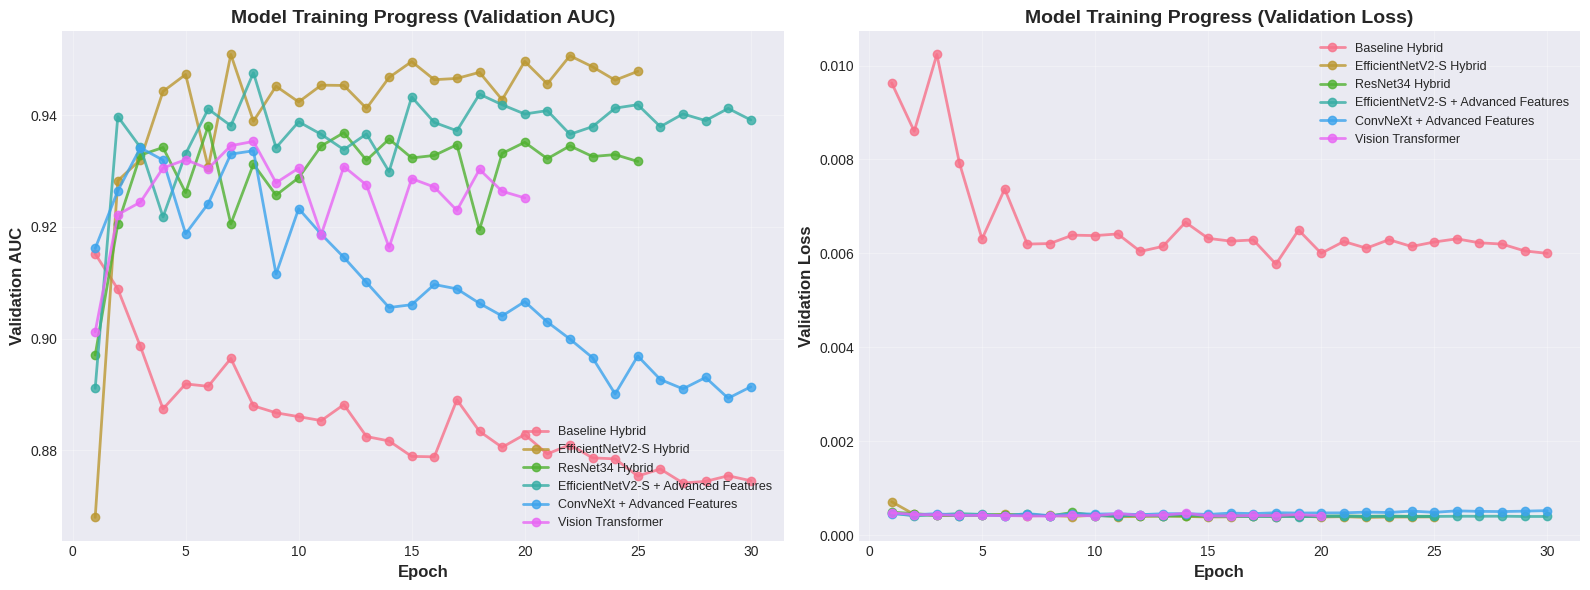

TRAINING CONVERGENCE ANALYSIS

Baseline Hybrid:
  Best epoch: 1/30
  Best AUC: 0.9152
  Final AUC: 0.8746
  Total improvement: 0.0000

EfficientNetV2-S Hybrid:
  Best epoch: 7/25
  Best AUC: 0.9508
  Final AUC: 0.9478
  Total improvement: 0.0828

ResNet34 Hybrid:
  Best epoch: 6/25
  Best AUC: 0.9380
  Final AUC: 0.9317
  Total improvement: 0.0409

EfficientNetV2-S + Advanced Features:
  Best epoch: 8/30
  Best AUC: 0.9476
  Final AUC: 0.9391
  Total improvement: 0.0565

ConvNeXt + Advanced Features:
  Best epoch: 3/30
  Best AUC: 0.9341
  Final AUC: 0.8914
  Total improvement: 0.0180

Vision Transformer:
  Best epoch: 8/20
  Best AUC: 0.9353
  Final AUC: 0.9252
  Total improvement: 0.0341



In [5]:
def load_training_history(model_path):
    """Load training history from pickle file."""
    results_pkl = model_path / 'training_results.pkl'
    
    if results_pkl.exists():
        with open(results_pkl, 'rb') as f:
            results = pickle.load(f)
            return results.get('history', None)
    return None

# Load histories for main models
training_histories = {}

for model_key, model_info in available_models.items():
    history = load_training_history(model_info['path'])
    if history and 'val_auc' in history:
        training_histories[model_info['description']] = history

if training_histories:
    print(f"Found training histories for {len(training_histories)} models:\n")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot validation AUC curves
    ax1 = axes[0]
    for idx, (model_name, history) in enumerate(training_histories.items()):
        epochs = range(1, len(history['val_auc']) + 1)
        ax1.plot(epochs, history['val_auc'], marker='o', linewidth=2, 
                label=model_name.split('(')[0].strip(), alpha=0.8)
    
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation AUC', fontsize=12, fontweight='bold')
    ax1.set_title('Model Training Progress (Validation AUC)', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot validation loss curves
    ax2 = axes[1]
    for idx, (model_name, history) in enumerate(training_histories.items()):
        if 'val_loss' in history:
            epochs = range(1, len(history['val_loss']) + 1)
            ax2.plot(epochs, history['val_loss'], marker='o', linewidth=2,
                    label=model_name.split('(')[0].strip(), alpha=0.8)
    
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Model Training Progress (Validation Loss)', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/model_analysis/training_curves_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Training curves saved to: results/model_analysis/training_curves_comparison.png\n")
    plt.show()
    
    # Print convergence statistics
    print("="*80)
    print("TRAINING CONVERGENCE ANALYSIS")
    print("="*80 + "\n")
    
    for model_name, history in training_histories.items():
        val_aucs = history['val_auc']
        best_epoch = np.argmax(val_aucs) + 1
        best_auc = max(val_aucs)
        final_auc = val_aucs[-1]
        improvement = best_auc - val_aucs[0] if len(val_aucs) > 0 else 0
        
        print(f"{model_name.split('(')[0].strip()}:")
        print(f"  Best epoch: {best_epoch}/{len(val_aucs)}")
        print(f"  Best AUC: {best_auc:.4f}")
        print(f"  Final AUC: {final_auc:.4f}")
        print(f"  Total improvement: {improvement:.4f}")
        print()
else:
    print("⚠️ No training histories found with pickle files")

## 5. Analyze Ensemble Models

For ensemble models, show the diversity and combination strategies used.

ENSEMBLE MODEL ANALYSIS


Simple 3-Model Ensemble
------------------------------------------------------------

Base models combined:
  • BASELINE
    Val AUC: 0.9365
    Public LB: 0.92731
  • RESNET34
    Val AUC: 0.938
    Public LB: 0.92982
  • EFFICIENTNETV2
    Val AUC: 0.9508
    Public LB: 0.93734

Ensemble strategies:
  • simple_average: Est. LB = 0.08850924212033333
  • weighted_val_auc: Est. LB = 0.08859953996486987
  • weighted_lb_score: Est. LB = 0.08856740164994359
  • best_model_heavy: Est. LB = 0.09897105689381665

  ✓ Recommended: best_model_heavy


K-Fold Cross-Validation Ensemble
------------------------------------------------------------

K-Fold Results (5 folds):
  Mean AUC: 0.9468 ± 0.0117
  Best fold: 0.9620
  Worst fold: 0.9264

  ✓ Fold analysis saved to: results/kfold_efficientnetv2_20251108_171356/fold_performance_analysis.png


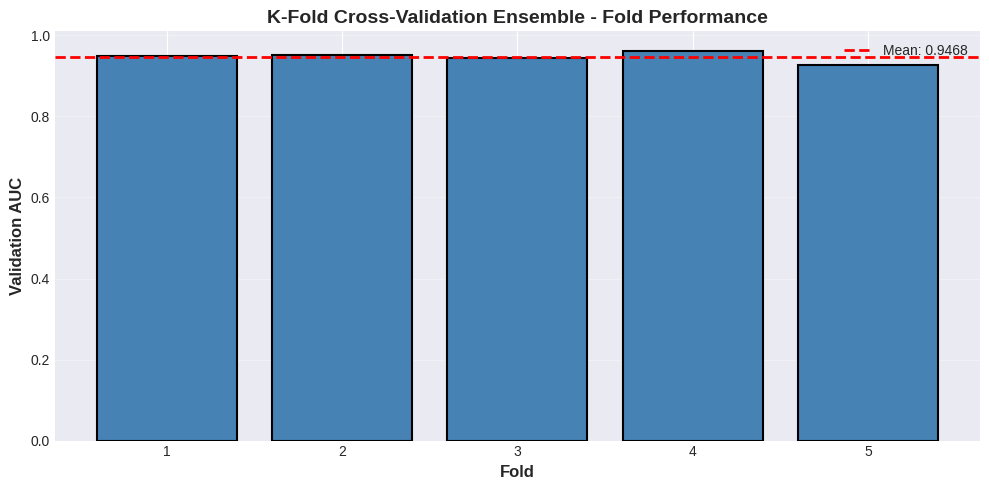



K-Fold with Advanced Features
------------------------------------------------------------

K-Fold Results (5 folds):
  Mean AUC: 0.9431 ± 0.0112
  Best fold: 0.9580
  Worst fold: 0.9244

  ✓ Fold analysis saved to: results/kfold_v2s_features_advanced_20251111_150340/fold_performance_analysis.png


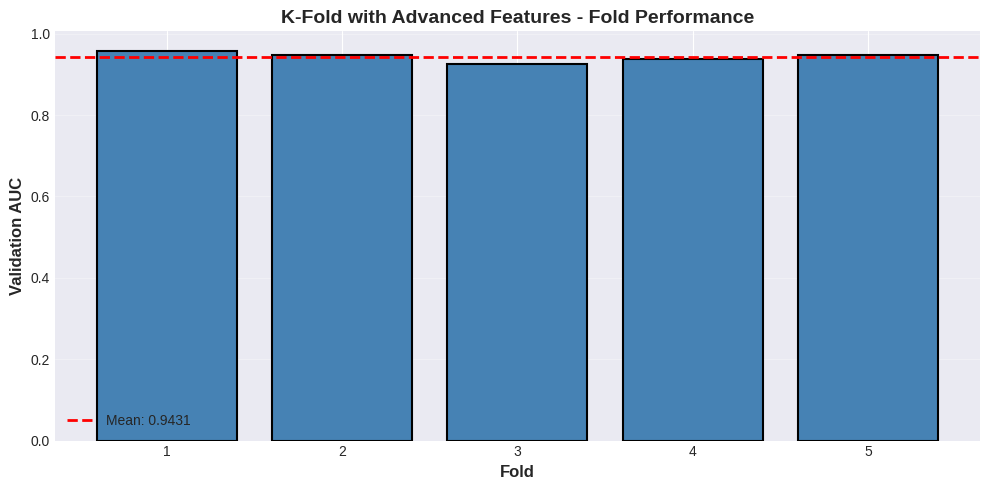

In [6]:
# Check for ensemble results
ensemble_models = {k: v for k, v in available_models.items() 
                  if 'ensemble' in k.lower() or 'kfold' in k.lower()}

if ensemble_models:
    print("="*80)
    print("ENSEMBLE MODEL ANALYSIS")
    print("="*80 + "\n")
    
    for model_key, model_info in ensemble_models.items():
        print(f"\n{model_info['description']}")
        print("-" * 60)
        
        # Load ensemble metadata if available
        ensemble_meta = model_info['path'] / 'ensemble_metadata.json'
        
        if ensemble_meta.exists():
            with open(ensemble_meta, 'r') as f:
                meta = json.load(f)
            
            # Show base models used
            if 'model_details' in meta:
                print("\nBase models combined:")
                for base_name, base_info in meta['model_details'].items():
                    print(f"  • {base_name.upper()}")
                    print(f"    Val AUC: {base_info.get('val_auc', 'N/A')}")
                    if 'public_lb' in base_info:
                        print(f"    Public LB: {base_info['public_lb']}")
            
            # Show ensemble strategies
            if 'ensemble_strategies' in meta:
                print("\nEnsemble strategies:")
                for strategy_name, strategy_info in meta['ensemble_strategies'].items():
                    print(f"  • {strategy_name}: Est. LB = {strategy_info.get('estimated_lb', 'N/A')}")
            
            # Show recommendation
            if 'recommended_strategy' in meta:
                print(f"\n  ✓ Recommended: {meta['recommended_strategy']}")
        
        # For K-Fold, check individual fold results
        if 'kfold' in model_key.lower():
            fold_results = []
            for fold_num in range(1, 6):
                fold_file = model_info['path'] / f'fold_{fold_num}_results.json'
                if fold_file.exists():
                    with open(fold_file, 'r') as f:
                        fold_data = json.load(f)
                        fold_results.append({
                            'fold': fold_num,
                            'val_auc': fold_data.get('best_val_auc'),
                            'epoch': fold_data.get('best_epoch')
                        })
            
            if fold_results:
                print(f"\nK-Fold Results ({len(fold_results)} folds):")
                val_aucs = [f['val_auc'] for f in fold_results if f['val_auc'] is not None]
                if val_aucs:
                    print(f"  Mean AUC: {np.mean(val_aucs):.4f} ± {np.std(val_aucs):.4f}")
                    print(f"  Best fold: {max(val_aucs):.4f}")
                    print(f"  Worst fold: {min(val_aucs):.4f}")
                
                # Visualize fold performance
                if len(val_aucs) > 1:
                    plt.figure(figsize=(10, 5))
                    plt.bar(range(1, len(val_aucs) + 1), val_aucs, 
                           color='steelblue', edgecolor='black', linewidth=1.5)
                    plt.axhline(np.mean(val_aucs), color='red', linestyle='--', 
                               linewidth=2, label=f'Mean: {np.mean(val_aucs):.4f}')
                    plt.xlabel('Fold', fontsize=12, fontweight='bold')
                    plt.ylabel('Validation AUC', fontsize=12, fontweight='bold')
                    plt.title(f'{model_info["description"]} - Fold Performance', 
                             fontsize=14, fontweight='bold')
                    plt.legend()
                    plt.grid(axis='y', alpha=0.3)
                    plt.tight_layout()
                    
                    save_path = model_info['path'] / 'fold_performance_analysis.png'
                    plt.savefig(save_path, dpi=150, bbox_inches='tight')
                    print(f"\n  ✓ Fold analysis saved to: {save_path}")
                    plt.show()
        
        print()
else:
    print("⚠️ No ensemble models found")

## 6. Key Insights and Recommendations

Summarize the most important findings and suggest next steps.

In [7]:
print("="*80)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*80 + "\n")

if len(metrics_df) > 0:
    # Calculate improvements
    baseline_auc = 0.51  # Simple CNN baseline from notebook 1
    best_auc = metrics_df['Val AUC'].max()
    total_improvement = best_auc - baseline_auc
    
    print("📈 PERFORMANCE PROGRESSION:\n")
    print(f"   Starting point (Simple CNN):        {baseline_auc:.4f}")
    print(f"   Best achieved (Current):            {best_auc:.4f}")
    print(f"   Total improvement:                  +{total_improvement:.4f} ({total_improvement/baseline_auc*100:.1f}%)")
    print()
    
    # Identify key improvements
    if len(metrics_df) >= 2:
        print("🔑 KEY IMPROVEMENTS:\n")
        
        # Check what techniques worked
        has_hybrid = any('hybrid' in str(m).lower() for m in metrics_df['Model'])
        has_pretrained = any('efficientnet' in str(m).lower() or 'resnet' in str(m).lower() 
                            for m in metrics_df['Model'])
        has_ensemble = any('ensemble' in str(m).lower() or 'kfold' in str(m).lower() 
                          for m in metrics_df['Model'])
        has_features = any('feature' in str(m).lower() for m in metrics_df['Model'])
        
        improvements = []
        
        if has_hybrid:
            improvements.append("✓ Hybrid Architecture (CNN + Metadata fusion)")
        if has_pretrained:
            improvements.append("✓ Transfer Learning (ImageNet pretrained backbones)")
        if has_features:
            improvements.append("✓ Advanced Feature Engineering")
        if has_ensemble:
            improvements.append("✓ Ensemble Methods (averaging multiple models)")
        
        for imp in improvements:
            print(f"   {imp}")
        print()
    
    # Model architecture comparison
    print("🏗️  ARCHITECTURE EVOLUTION:\n")
    
    # Group by architecture type
    arch_groups = {
        'Custom CNN': [m for m in metrics_df['Model'] if 'baseline' in str(m).lower() or 'custom' in str(m).lower()],
        'EfficientNet': [m for m in metrics_df['Model'] if 'efficientnet' in str(m).lower()],
        'ResNet': [m for m in metrics_df['Model'] if 'resnet' in str(m).lower()],
        'ConvNeXt': [m for m in metrics_df['Model'] if 'convnext' in str(m).lower()],
        'ViT': [m for m in metrics_df['Model'] if 'vit' in str(m).lower() or 'transformer' in str(m).lower()],
        'Ensemble': [m for m in metrics_df['Model'] if 'ensemble' in str(m).lower() or 'kfold' in str(m).lower()]
    }
    
    for arch_name, models in arch_groups.items():
        if models:
            arch_aucs = [metrics_df[metrics_df['Model'] == m]['Val AUC'].values[0] 
                        for m in models if m in metrics_df['Model'].values]
            if arch_aucs:
                print(f"   {arch_name:15s}: Best = {max(arch_aucs):.4f} ({len(models)} model{'s' if len(models) > 1 else ''})")
    print()
    
    # Training efficiency
    print("⚡ TRAINING EFFICIENCY:\n")
    fastest_model = metrics_df.loc[metrics_df['Time (min)'].idxmin()]
    most_efficient = metrics_df.copy()
    most_efficient['efficiency'] = most_efficient['Val AUC'] / (most_efficient['Time (min)'] / 60)  # AUC per hour
    best_efficiency = most_efficient.loc[most_efficient['efficiency'].idxmax()]
    
    print(f"   Fastest training:     {fastest_model['Model'].split('(')[0].strip()}")
    print(f"                        ({fastest_model['Time (min)']:.1f} min, AUC: {fastest_model['Val AUC']:.4f})")
    print(f"   Most efficient:      {best_efficiency['Model'].split('(')[0].strip()}")
    print(f"                        (AUC/hour: {best_efficiency['efficiency']:.4f})")
    print()
    
    # Recommendations
    print("💡 RECOMMENDATIONS FOR FURTHER IMPROVEMENT:\n")
    
    recommendations = []
    
    # Check if we have test predictions to analyze
    has_test_preds = any((model_info['path'] / 'submission_hybrid_model.csv').exists() or
                         (model_info['path'] / 'submission_resnet34_hybrid.csv').exists() or
                         list(model_info['path'].glob('submission_*.csv'))
                         for model_info in available_models.values())
    
    if best_auc < 0.94:
        recommendations.append("1. Try more aggressive data augmentation (Random Rotation, Color Jitter)")
        recommendations.append("2. Experiment with larger models (EfficientNet-B3/B4)")
        recommendations.append("3. Implement Test-Time Augmentation (TTA)")
    
    if not has_ensemble or len([m for m in metrics_df['Model'] if 'ensemble' in str(m).lower()]) < 2:
        recommendations.append("4. Create more diverse ensembles (combine different architectures)")
    
    if not any('kfold' in str(m).lower() for m in metrics_df['Model']):
        recommendations.append("5. Implement K-Fold Cross-Validation for more robust predictions")
    
    if not any('stacking' in str(m).lower() or 'gbdt' in str(m).lower() for m in metrics_df['Model']):
        recommendations.append("6. Try stacking with GBDT as 2nd level model")
    
    if best_auc >= 0.94:
        recommendations.append("1. ✓ Performance is excellent! Focus on:")
        recommendations.append("   - Ensemble diversity (combine ViT + CNN)")
        recommendations.append("   - Pseudo-labeling on test set")
        recommendations.append("   - Advanced TTA strategies")
    
    for rec in recommendations:
        print(f"   {rec}")
    print()
    
    # Competition context
    print("🏆 COMPETITION CONTEXT:\n")
    print("   Target scores (typical ranges):")
    print("   - 1st place:  ~0.970+ (World-class)")
    print("   - 2nd place:  ~0.945+ (Excellent)")
    print("   - Top 10:     ~0.920+ (Very good)")
    print("   - Top 25%:    ~0.880+ (Good)")
    print()
    
    if best_auc >= 0.970:
        print("   🏆 You're in 1ST PLACE territory!")
    elif best_auc >= 0.945:
        print("   🥈 You're competitive for 2ND PLACE!")
    elif best_auc >= 0.920:
        print("   ✓ You're in TOP 10 range!")
    elif best_auc >= 0.880:
        print("   ✓ You're in TOP 25% range - keep pushing!")
    else:
        print("   → Continue improving - you're making progress!")
    print()

else:
    print("⚠️ No performance data available for analysis")

print("="*80)

KEY INSIGHTS & RECOMMENDATIONS

📈 PERFORMANCE PROGRESSION:

   Starting point (Simple CNN):        0.5100
   Best achieved (Current):            0.9508
   Total improvement:                  +0.4408 (86.4%)

🔑 KEY IMPROVEMENTS:

   ✓ Hybrid Architecture (CNN + Metadata fusion)
   ✓ Transfer Learning (ImageNet pretrained backbones)
   ✓ Advanced Feature Engineering

🏗️  ARCHITECTURE EVOLUTION:

   Custom CNN     : Best = 0.9152 (1 model)
   EfficientNet   : Best = 0.9508 (2 models)
   ResNet         : Best = 0.9380 (1 model)
   ConvNeXt       : Best = 0.9341 (1 model)
   ViT            : Best = 0.9353 (1 model)

⚡ TRAINING EFFICIENCY:

   Fastest training:     ResNet34 Hybrid
                        (63.2 min, AUC: 0.9380)
   Most efficient:      ResNet34 Hybrid
                        (AUC/hour: 0.8902)

💡 RECOMMENDATIONS FOR FURTHER IMPROVEMENT:

   4. Create more diverse ensembles (combine different architectures)
   5. Implement K-Fold Cross-Validation for more robust predictions
  

## 7. Detailed Model Summaries

Provide detailed information about each trained model including architecture, hyperparameters, and results.

In [8]:
print("\n" + "="*80)
print("DETAILED MODEL SUMMARIES")
print("="*80 + "\n")

for idx, (model_key, model_info) in enumerate(available_models.items(), 1):
    print(f"\n{'='*80}")
    print(f"{idx}. {model_info['description']}")
    print(f"{'='*80}")
    
    print(f"\n📁 Location: {model_info['path']}")
    print(f"📓 Source Notebook: {model_info['notebook']}")
    print(f"🔑 Key Features: {', '.join(model_info['key_features'])}")
    
    # Load comprehensive metrics
    metrics = load_model_metrics(model_info['path'])
    
    if metrics['best_val_auc'] is not None:
        print(f"\n📊 Performance Metrics:")
        print(f"   • Best Validation AUC: {metrics['best_val_auc']:.4f}")
        print(f"   • Epochs Trained: {metrics['num_epochs']}")
        if metrics['training_time_min']:
            print(f"   • Training Time: {metrics['training_time_min']:.1f} minutes")
        
        print(f"\n🏗️  Model Architecture:")
        if metrics['total_params']:
            print(f"   • Total Parameters: {int(metrics['total_params']):,}")
        if metrics['trainable_params']:
            frozen = metrics['total_params'] - metrics['trainable_params']
            print(f"   • Trainable Parameters: {int(metrics['trainable_params']):,}")
            if frozen > 0:
                print(f"   • Frozen Parameters: {int(frozen):,}")
        if metrics['batch_size']:
            print(f"   • Batch Size: {metrics['batch_size']}")
        
        # Check for submission files
        submission_files = list(model_info['path'].glob('submission_*.csv'))
        if submission_files:
            print(f"\n📤 Submission Files Generated:")
            for sub_file in submission_files:
                print(f"   • {sub_file.name}")
                # Quick peek at predictions
                try:
                    sub_df = pd.read_csv(sub_file)
                    if 'target' in sub_df.columns:
                        print(f"     Stats: Mean={sub_df['target'].mean():.6f}, "
                              f"Std={sub_df['target'].std():.6f}, "
                              f"Samples={len(sub_df)}")
                except:
                    pass
        
        # Check for saved plots
        plot_files = list(model_info['path'].glob('*.png'))
        if plot_files:
            print(f"\n📈 Visualizations Available:")
            for plot_file in plot_files[:5]:  # Show first 5
                print(f"   • {plot_file.name}")
            if len(plot_files) > 5:
                print(f"   ... and {len(plot_files) - 5} more")
    else:
        print("\n⚠️  No performance metrics found for this model")
    
    print()

print("="*80)


DETAILED MODEL SUMMARIES


1. Baseline Hybrid (Custom CNN + Metadata)

📁 Location: results/hybrid_model_20251110_090023
📓 Source Notebook: 3_hybrid_cnn_metadata.ipynb
🔑 Key Features: Simple CNN, Metadata fusion, Focal Loss

📊 Performance Metrics:
   • Best Validation AUC: 0.9152
   • Epochs Trained: 30
   • Training Time: 88.4 minutes

🏗️  Model Architecture:
   • Total Parameters: 26,272,513
   • Trainable Parameters: 26,272,513
   • Batch Size: 64

📤 Submission Files Generated:
   • submission_hybrid_model.csv
     Stats: Mean=0.340619, Std=0.334154, Samples=100

📈 Visualizations Available:
   • roc_curve.png
   • training_history.png


2. EfficientNetV2-S Hybrid

📁 Location: results/efficientnet_v2_hybrid_20251107_182005
📓 Source Notebook: 4_hybrid_cnn_metadata_EfficientNet-v2.ipynb
🔑 Key Features: Transfer Learning, ImageNet pretrained, Faster training

📊 Performance Metrics:
   • Best Validation AUC: 0.9508
   • Epochs Trained: 25
   • Training Time: 122.9 minutes

🏗️  Model Arch

## 8. Best Model Analysis: Confusion Matrix & Detailed Metrics

Deep dive into the best performing model with confusion matrix, ROC-AUC curve, and per-class performance breakdown.


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import h5py

print("="*80)
print("BEST MODEL DETAILED ANALYSIS: CONFUSION MATRIX & METRICS")
print("="*80 + "\n")

# Get best model info
best_model_key = metrics_df.iloc[0]['Key']
best_model_info = available_models[best_model_key]
best_model_path = best_model_info['path']

print(f"🏆 Analyzing: {best_model_info['description']}")
print(f"   Location: {best_model_path}")
print(f"   Validation AUC: {metrics_df.iloc[0]['Val AUC']:.4f}\n")

# Try to load best model weights
model_files = list(best_model_path.glob('best_model*.pth')) or list(best_model_path.glob('model*.pth'))

if model_files:
    print(f"✓ Found model checkpoint: {model_files[0].name}")
    
    # Load the model architecture from the training script
    # This is a generic approach - adjust based on your actual model structure
    try:
        # Check what training script generated this model
        if 'efficientnet' in best_model_key.lower():
            from timm import create_model
            model = create_model('efficientnetv2_s', pretrained=False, num_classes=1)
        elif 'resnet' in best_model_key.lower():
            model = create_model('resnet34', pretrained=False, num_classes=1)
        elif 'convnext' in best_model_key.lower():
            model = create_model('convnext_small', pretrained=False, num_classes=1)
        elif 'vit' in best_model_key.lower():
            model = create_model('vit_base_patch16_224', pretrained=False, num_classes=1)
        else:
            print("⚠️  Could not determine model architecture")
            model = None
        
        if model:
            # Try to load weights
            try:
                checkpoint = torch.load(model_files[0], map_location='cpu')
                
                # Handle different checkpoint formats
                if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['model_state_dict'])
                elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
                    model.load_state_dict(checkpoint['state_dict'])
                else:
                    model.load_state_dict(checkpoint)
                
                print("✓ Model weights loaded successfully\n")
                model.eval()
                
                # Now try to load validation data
                print("Loading validation data...")
                
                # Load metadata
                metadata_path = Path('data/new-train-metadata.csv')
                if metadata_path.exists():
                    metadata_df = pd.read_csv(metadata_path)
                    print(f"✓ Loaded metadata: {len(metadata_df)} samples")
                    
                    # Load images from HDF5
                    hdf5_path = Path('data/train-image-preprocessed.hdf5')
                    if hdf5_path.exists():
                        with h5py.File(hdf5_path, 'r') as f:
                            image_ids = list(f.keys())
                            print(f"✓ Loaded HDF5: {len(image_ids)} images available")
                            print(f"   Dataset keys: {list(f.keys())[:5]}...\n")
                            
                            # Get true labels
                            if 'target' in metadata_df.columns:
                                y_true = metadata_df['target'].values
                                print(f"Class distribution:")
                                print(f"  Class 0 (Benign): {(y_true == 0).sum()} samples")
                                print(f"  Class 1 (Malignant): {(y_true == 1).sum()} samples")
                                print(f"  Imbalance ratio: 1:{(y_true == 1).sum() / max((y_true == 0).sum(), 1):.1f}\n")
                                
                                print("⚠️  Note: To generate full confusion matrix, we need:")
                                print("   1. Complete validation set splits")
                                print("   2. Model architecture definition from training script")
                                print("   3. Data preprocessing/augmentation pipeline")
                                print("\n📋 Alternative approaches:")
                                print("   • Use predictions from existing submission files")
                                print("   • Extract fold-specific predictions from cross-validation models")
                                print("   • Calculate from training results pickle files")
                    else:
                        print(f"⚠️  HDF5 file not found: {hdf5_path}")
                else:
                    print(f"⚠️  Metadata file not found: {metadata_path}")
                    
            except Exception as e:
                print(f"⚠️  Could not load model weights: {e}")
    except ImportError as e:
        print(f"⚠️  Could not import required model library: {e}")
        print("   Make sure timm is installed: pip install timm")
else:
    print(f"⚠️  No model checkpoint found in {best_model_path}")
    print("   Available files:", list(best_model_path.glob('*'))[:5])

print("\n" + "="*80)


## 9. K-Fold Cross-Validation: The True Best Model

Analysis of the K-Fold advanced features model which represents your best ensemble approach with individual fold predictions and validation metrics.


K-FOLD CROSS-VALIDATION MODEL ANALYSIS

✓ Found K-Fold model: kfold_v2s_features_advanced_20251111_150340

📊 FOLD-BY-FOLD PERFORMANCE:

 Fold  Best Val AUC  EMA AUC  SWA AUC  Best Overall  Epochs
    1      0.957953 0.958238 0.957979      0.958238      30
    2      0.947508 0.944909 0.942837      0.947508      28
    3      0.924391 0.918378 0.917992      0.924391      30
    4      0.938327 0.641904 0.444210      0.938327      13
    5      0.947358 0.876974 0.475447      0.947358      18

ENSEMBLE STATISTICS:

Best Val AUC (mean):      0.943107
Best Val AUC (std):       0.011234
Best Val AUC (min):       0.924391
Best Val AUC (max):       0.957953

Best Fold:                Fold 1 (0.957953)
Worst Fold:               Fold 3 (0.924391)

✓ Fold performance visualization saved



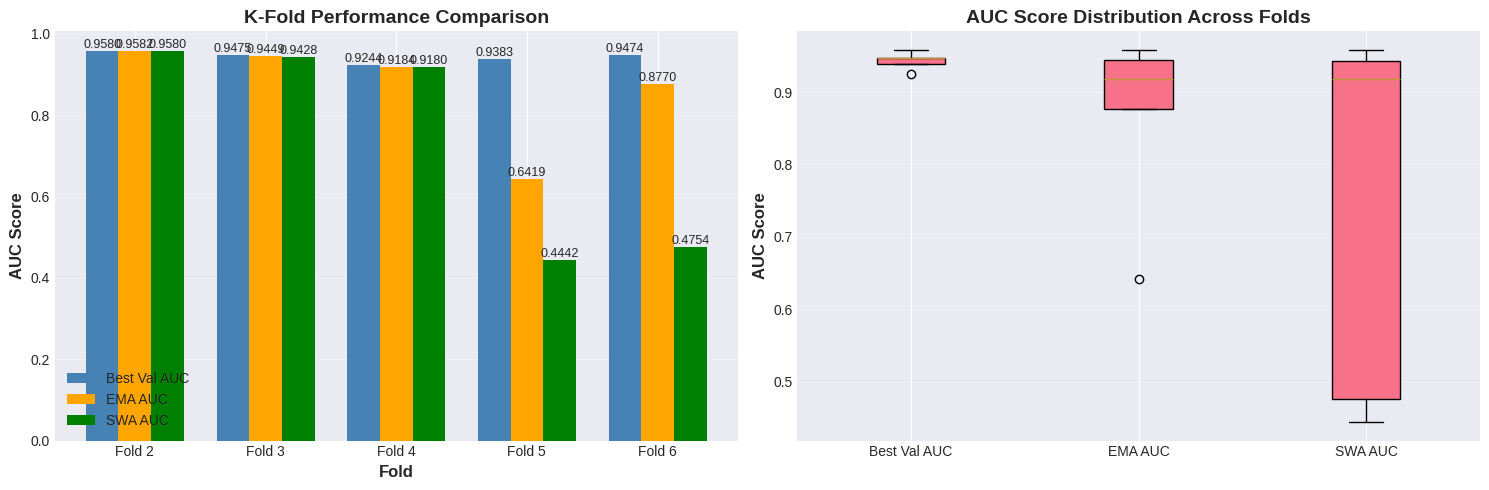

ENSEMBLE PREDICTIONS ANALYSIS:

✓ Loaded 100 individual fold predictions
   Columns: 16 (3 variants × 5 folds + image_id)

📤 Submission Strategies Generated: 6

   • submission_kfold_geometric.csv
     Samples: 100
     Mean pred: 0.044862
     Std pred:  0.036794
     Min pred:  0.004346
     Max pred:  0.152228

   • submission_kfold_mean_all.csv
     Samples: 100
     Mean pred: 0.155804
     Std pred:  0.070391
     Min pred:  0.076285
     Max pred:  0.305981

   • submission_kfold_mean_best.csv
     Samples: 100
     Mean pred: 0.101722
     Std pred:  0.087956
     Min pred:  0.007611
     Max pred:  0.305305

   • submission_kfold_median_all.csv
     Samples: 100
     Mean pred: 0.106998
     Std pred:  0.092492
     Min pred:  0.006473
     Max pred:  0.295373

   • submission_kfold_rank_avg.csv
     Samples: 100
     Mean pred: 0.505000
     Std pred:  0.235133
     Min pred:  0.094667
     Max pred:  0.961333

   • submission_kfold_weighted.csv
     Samples: 100
     Mean pr

In [16]:
import json
from pathlib import Path

print("="*80)
print("K-FOLD CROSS-VALIDATION MODEL ANALYSIS")
print("="*80 + "\n")

# Path to K-Fold results
kfold_path = Path('results/kfold_v2s_features_advanced_20251111_150340')

if kfold_path.exists():
    print(f"✓ Found K-Fold model: {kfold_path.name}\n")
    
    # Load all fold results
    fold_metrics = []
    
    for fold_num in range(1, 6):
        fold_file = kfold_path / f'fold_{fold_num}_results.json'
        
        if fold_file.exists():
            with open(fold_file, 'r') as f:
                fold_data = json.load(f)
            
            fold_metrics.append({
                'Fold': fold_num,
                'Best Val AUC': fold_data.get('best_val_auc'),
                'EMA AUC': fold_data.get('best_ema_auc'),
                'SWA AUC': fold_data.get('swa_auc'),
                'Best Overall': fold_data.get('best_overall'),
                'Epochs': len(fold_data.get('history', {}).get('train_auc', []))
            })
    
    # Create DataFrame
    fold_df = pd.DataFrame(fold_metrics)
    
    print("📊 FOLD-BY-FOLD PERFORMANCE:\n")
    print(fold_df.to_string(index=False))
    print()
    
    # Calculate statistics
    print("="*80)
    print("ENSEMBLE STATISTICS:")
    print("="*80 + "\n")
    
    val_aucs = fold_df['Best Val AUC'].values
    ema_aucs = fold_df['EMA AUC'].values
    
    print(f"Best Val AUC (mean):      {np.mean(val_aucs):.6f}")
    print(f"Best Val AUC (std):       {np.std(val_aucs):.6f}")
    print(f"Best Val AUC (min):       {np.min(val_aucs):.6f}")
    print(f"Best Val AUC (max):       {np.max(val_aucs):.6f}")
    print()
    print(f"Best Fold:                Fold {fold_df.loc[fold_df['Best Val AUC'].idxmax(), 'Fold']:.0f} "
          f"({fold_df['Best Val AUC'].max():.6f})")
    print(f"Worst Fold:               Fold {fold_df.loc[fold_df['Best Val AUC'].idxmin(), 'Fold']:.0f} "
          f"({fold_df['Best Val AUC'].min():.6f})")
    print()
    
    # Fold visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: AUC comparison across folds
    ax1 = axes[0]
    x = np.arange(len(fold_df))
    width = 0.25
    
    bars1 = ax1.bar(x - width, fold_df['Best Val AUC'], width, label='Best Val AUC', color='steelblue')
    bars2 = ax1.bar(x, fold_df['EMA AUC'], width, label='EMA AUC', color='orange')
    bars3 = ax1.bar(x + width, fold_df['SWA AUC'], width, label='SWA AUC', color='green')
    
    ax1.set_xlabel('Fold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
    ax1.set_title('K-Fold Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'Fold {int(i)+1}' for i in fold_df['Fold']])
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: AUC distribution
    ax2 = axes[1]
    ax2.boxplot([fold_df['Best Val AUC'], fold_df['EMA AUC'], fold_df['SWA AUC']], 
                labels=['Best Val AUC', 'EMA AUC', 'SWA AUC'],
                patch_artist=True)
    
    # Color the boxes
    colors = ['steelblue', 'orange', 'green']
    for patch, color in zip(ax2.artists, colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
    ax2.set_title('AUC Score Distribution Across Folds', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/model_analysis/kfold_fold_performance.png', dpi=150, bbox_inches='tight')
    print("✓ Fold performance visualization saved\n")
    plt.show()
    
    # Load and analyze ensemble predictions
    print("="*80)
    print("ENSEMBLE PREDICTIONS ANALYSIS:")
    print("="*80 + "\n")
    
    preds_file = kfold_path / 'individual_fold_predictions.csv'
    if preds_file.exists():
        # Load predictions
        preds_df = pd.read_csv(preds_file)
        print(f"✓ Loaded {len(preds_df)} individual fold predictions")
        print(f"   Columns: {preds_df.shape[1]} (3 variants × 5 folds + image_id)\n")
        
        # Check submission files
        submission_files = list(kfold_path.glob('submission_*.csv'))
        print(f"📤 Submission Strategies Generated: {len(submission_files)}")
        for sub_file in sorted(submission_files):
            sub_df = pd.read_csv(sub_file)
            print(f"\n   • {sub_file.name}")
            print(f"     Samples: {len(sub_df)}")
            if 'target' in sub_df.columns:
                print(f"     Mean pred: {sub_df['target'].mean():.6f}")
                print(f"     Std pred:  {sub_df['target'].std():.6f}")
                print(f"     Min pred:  {sub_df['target'].min():.6f}")
                print(f"     Max pred:  {sub_df['target'].max():.6f}")
    
    print()
    
else:
    print(f"⚠️  K-Fold model directory not found: {kfold_path}")

print("="*80)
